# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA only if the numerical features show a correlation.


In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')

In [131]:
print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [132]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [133]:
df_quantitive = df.select_dtypes(include=['number'])

In [134]:
# Calculate the sum of missing values per column
missing_values = df.isna().sum()

# Filter and display ONLY the columns where missing values are greater than 0
print(missing_values[missing_values > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [135]:
df_quantitive

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,366,0,112,0,0,0,0,4,2010,142125


In [136]:
missing_values = df_quantitive.isna().sum()

print(missing_values[missing_values > 0])

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64


now dealing with this missing values

MasVnrArea       8  Remove it since it is small part of the data

GarageYrBlt     81  Make it 0 because it probably means no grage space that way it is not recorded

LotFrontage    259  Replace it with the median because it will be better then using the mean that will be affected by outliar

In [ ]:
df_quantitive = df_quantitive[df_quantitive['MasVnrArea'].notna()]
df_quantitive['GarageYrBlt'] = df_quantitive['GarageYrBlt'].fillna(0)
df_quantitive['LotFrontage'] = df_quantitive['LotFrontage'].fillna(df_quantitive['LotFrontage'].median())
df_quantitive[['MasVnrArea','GarageYrBlt','LotFrontage']].isna().sum()




Id               0
MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

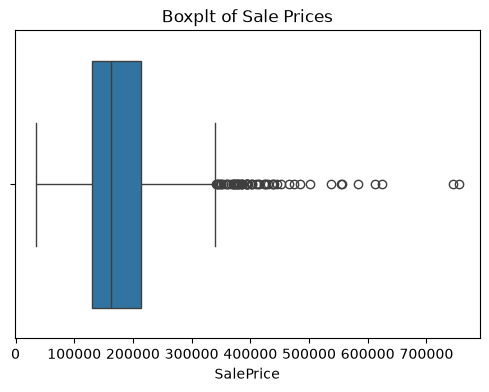

In [146]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_quantitive['SalePrice'])

plt.title('Boxplt of Sale Prices')
plt.show()

In [138]:
Q1 = df_quantitive.quantile(0.25)
Q3 = df_quantitive.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_quantitive[(df_quantitive < lower) | (df_quantitive > upper)]


# Create an empty dictionary to store arrays of varying lengths
outliers_per_feature = {}

# Loop through every single column in the DataFrame
for col in df_quantitive.columns:
    # 1. Find rows where this specific column exceeds its lower or upper bounds
    is_outlier = (df_quantitive[col] < lower[col]) | (df_quantitive[col] > upper[col])
    
    # 2. Extract those values, drop any NaNs, and convert them to a Python list
    clean_outliers = df_quantitive[col][is_outlier].dropna().tolist()
    
    # 3. Save the list to our dictionary only if the feature actually has outliers
    if len(clean_outliers) > 0:
        outliers_per_feature[col] = clean_outliers

# Print each feature and its isolated array of outliers
for feature, values in outliers_per_feature.items():
    print(f"{feature} Outliers (Total: {len(values)})")
    print(values)
    print("-" * 40)


MSSubClass Outliers (Total: 103)
[190, 190, 160, 180, 160, 190, 160, 190, 160, 190, 160, 160, 160, 160, 160, 160, 160, 160, 160, 190, 160, 190, 190, 190, 190, 160, 160, 160, 190, 160, 160, 180, 180, 190, 180, 160, 160, 160, 190, 190, 160, 160, 160, 180, 160, 190, 190, 180, 160, 160, 160, 160, 190, 190, 190, 160, 160, 160, 160, 160, 190, 160, 160, 160, 160, 160, 190, 160, 160, 190, 160, 160, 190, 160, 180, 190, 160, 160, 160, 160, 160, 190, 160, 160, 190, 190, 160, 160, 160, 160, 190, 160, 180, 160, 160, 160, 160, 160, 160, 190, 190, 180, 180]
----------------------------------------
LotFrontage Outliers (Total: 106)
[110.0, 108.0, 112.0, 115.0, 110.0, 24.0, 21.0, 121.0, 122.0, 24.0, 120.0, 134.0, 110.0, 141.0, 24.0, 24.0, 174.0, 21.0, 21.0, 174.0, 21.0, 21.0, 120.0, 30.0, 129.0, 140.0, 120.0, 118.0, 116.0, 150.0, 111.0, 21.0, 109.0, 130.0, 21.0, 24.0, 21.0, 137.0, 110.0, 21.0, 21.0, 24.0, 130.0, 24.0, 30.0, 21.0, 21.0, 21.0, 120.0, 110.0, 24.0, 24.0, 30.0, 110.0, 144.0, 114.0, 24.0, 30

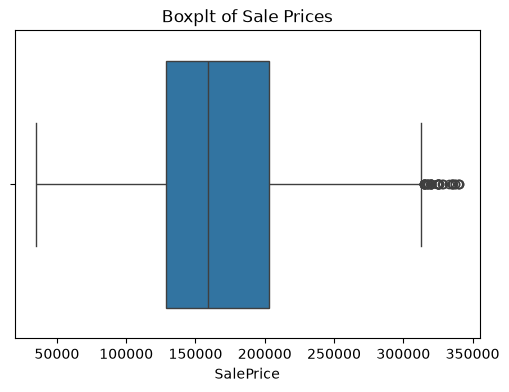

In [154]:
df_quantitive_no_outliers = df_quantitive[(df_quantitive >= lower) & (df_quantitive <= upper)]
plt.figure(figsize=(6,4))
sns.boxplot(x=df_quantitive_no_outliers['SalePrice'])

plt.title('Boxplt of Sale Prices')
plt.show()

